# Credit Card Fraud Detection(EDA)

## Setup & Imports


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


## Load & Explore Data


In [4]:
df = pd.read_csv('Data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.shape

(284807, 31)

In [6]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.86,47488.15,0.00,54201.50,84692.00,139320.50,172792.00
V1,284807.0,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V2,284807.0,0.00,1.65,-72.72,-0.60,0.07,0.80,22.06
V3,284807.0,-0.00,1.52,-48.33,-0.89,0.18,1.03,9.38
V4,284807.0,0.00,1.42,-5.68,-0.85,-0.02,0.74,16.88
V5,284807.0,0.00,1.38,-113.74,-0.69,-0.05,0.61,34.80
V6,284807.0,0.00,1.33,-26.16,-0.77,-0.27,0.40,73.30
V7,284807.0,-0.00,1.24,-43.56,-0.55,0.04,0.57,120.59
V8,284807.0,0.00,1.19,-73.22,-0.21,0.02,0.33,20.01
V9,284807.0,-0.00,1.10,-13.43,-0.64,-0.05,0.60,15.59


In [7]:
class_count = df['Class'].value_counts().sort_index()
class_percentages = df['Class'].value_counts(normalize=True).sort_index().round(2) * 100
class_distribution = pd.DataFrame({
    'count': class_count,
    'percentage': class_percentages
})
class_distribution.index = ["Legitimate (0)", "Fraud (1)"]
class_distribution

,count,percentage
Legitimate (0),284315,100.0
Fraud (1),492,0.0


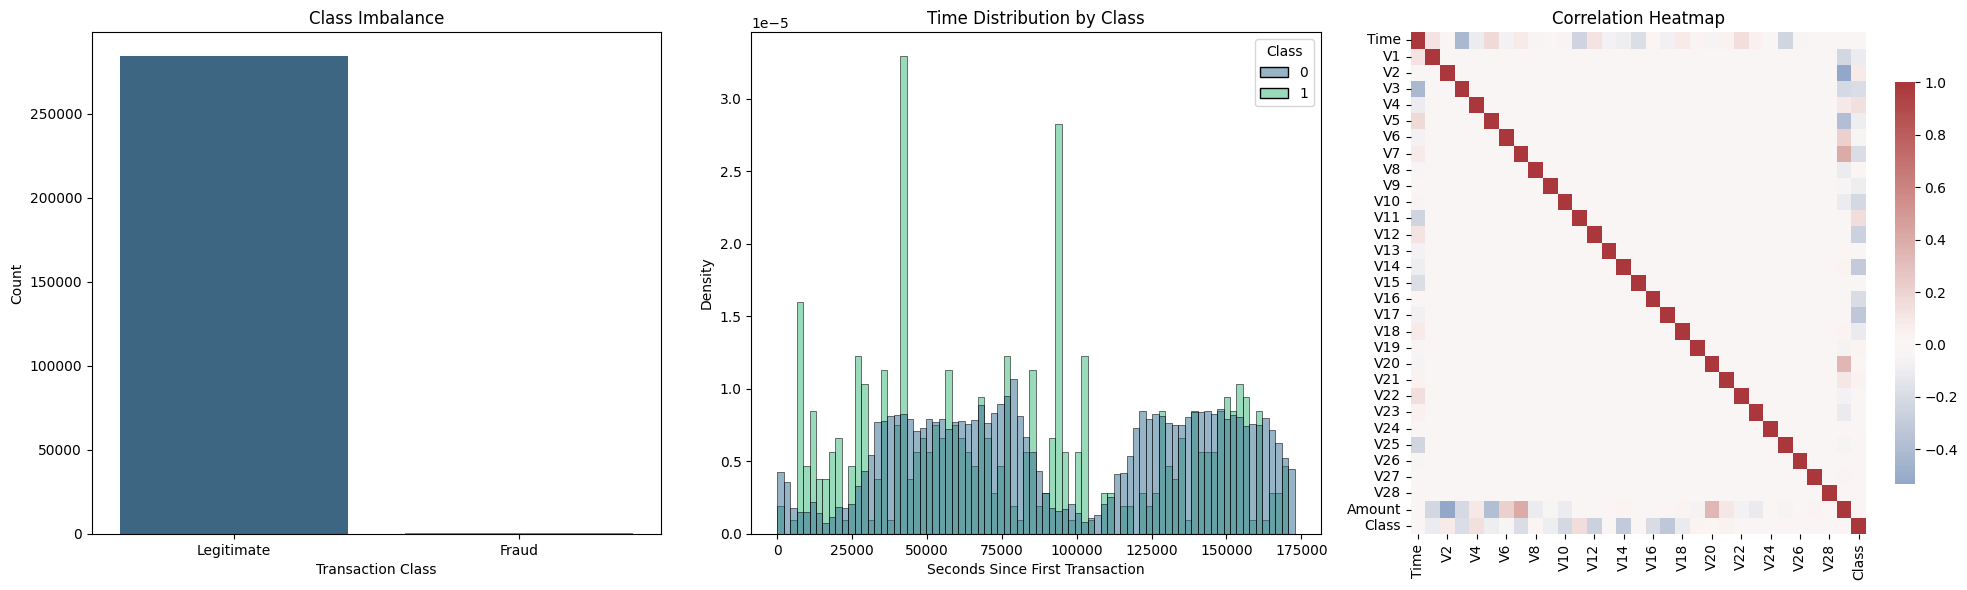

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(data=df, x="Class", ax=axes[0], palette="viridis")
axes[0].set_title("Class Imbalance")
axes[0].set_xticklabels(["Legitimate", "Fraud"])
axes[0].set_xlabel("Transaction Class")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="Time", hue="Class", bins=80, stat="density", common_norm=False, ax=axes[1], palette="viridis")
axes[1].set_title("Time Distribution by Class")
axes[1].set_xlabel("Seconds Since First Transaction")
axes[1].set_ylabel("Density")

corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0, square=False, cbar_kws={"shrink": 0.8}, ax=axes[2])
axes[2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()